# BindCraft — local Windows / WSL notebook

Adapted from `notebooks/BindCraft.ipynb` for this checkout. Open this notebook in
your existing **Windows Jupyter Python 3 kernel**, or in Jupyter inside Ubuntu.
Scientific computation runs in your existing **Ubuntu / BindCraft Python 3.10**
environment. The notebook calls the repository's `bindcraft.py` so its design,
MPNN, relaxation, and filtering logic stay in one place.

Run the cells in order. Review the target settings, then set `RUN_DESIGN = True`
in **Start a design run** when ready. The run starts in the background; use the
status and stop cells below. Running all cells with their saved defaults checks
the environment and prepares settings without starting a design campaign.

| Detected on 2026-09-12 | Value |
|---|---|
| Windows checkout | `C:\Users\Feres\Dropbox\Projects\BindCraft\BindCraft` |
| Ubuntu checkout | `/mnt/c/Users/Feres/Dropbox/Projects/BindCraft/BindCraft` |
| Compute Python | `/home/fereshteh/miniconda3/envs/BindCraft/bin/python` |
| GPU | RTX 4060 Laptop, 8,188 MiB VRAM |
| JAX / NumPy | 0.6.0 / 1.26.4 |
| ColabDesign / PyRosetta | 1.1.3 / 2026.29 quarterly |
| Existing inputs | 15 AlphaFold parameter files; `example/PDL1.pdb`, chain A, 115 residues |

The bundled DSSP 2.0.4 crashes on this WSL installation. This notebook uses the
separate DSSP 3.0.0 installation in `.bindcraft-local/dssp`. It also supplies the
BindCraft environment's library path so DAlphaBall can find `libgfortran.so.5`.
The repair cell below can recreate the separate DSSP installation if needed.

Your 8 GB GPU is below the repository's recommended 32 GB. The initial settings
limit binder length and sampling, but **a full design may still run out of memory**.
The setup check tests a small GPU operation, not a full AlphaFold design. Use a
smaller prepared target or a larger GPU if necessary; the notebook does not trim
your target automatically. See [environment notes](BindCraft_local_environment.md).

In [124]:
# Locate this checkout and select the existing Linux compute environment.
import csv
import html
import json
import os
import re
import shutil
import subprocess
import sys
import textwrap
import uuid
from datetime import datetime
from pathlib import Path, PurePosixPath
from IPython.display import HTML, display

REPO_OVERRIDE = ""  # Usually leave empty; otherwise use a path visible to this kernel.
WSL_DISTRO = "Ubuntu"
LINUX_PYTHON = "/home/fereshteh/miniconda3/envs/BindCraft/bin/python"
LINUX_CONDA = "/home/fereshteh/miniconda3/bin/conda"

def find_repo():
    if REPO_OVERRIDE:
        candidates = [Path(REPO_OVERRIDE).expanduser()]
    else:
        here = Path.cwd().resolve()
        candidates = [here, *here.parents]
        candidates += [Path(r"C:\Users\Feres\Dropbox\Projects\BindCraft\BindCraft")
                       if os.name == "nt" else
                       Path("/mnt/c/Users/Feres/Dropbox/Projects/BindCraft/BindCraft")]
    for candidate in candidates:
        if (candidate / "bindcraft.py").is_file() and (candidate / "functions").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Set REPO_OVERRIDE to the folder containing bindcraft.py.")

REPO_ROOT = find_repo()
USE_WSL = os.name == "nt"
HOST_PROCESS_OPTIONS = {"creationflags": subprocess.CREATE_NO_WINDOW} if USE_WSL else {}
if USE_WSL and not shutil.which("wsl.exe"):
    raise RuntimeError("wsl.exe was not found. Open this notebook in Ubuntu Jupyter.")
if not USE_WSL and not sys.platform.startswith("linux"):
    raise RuntimeError("The compute runtime must be Linux or Windows with WSL2.")

def local_path(value):
    """Interpret user paths on the notebook side; relative paths start at the repo."""
    value = str(value)
    if USE_WSL:
        match = re.match(r"^/mnt/([a-zA-Z])/(.*)$", value)
        if match:
            value = match[1].upper() + ":/" + match[2]
        elif value.startswith("/"):
            raise ValueError("Use a Windows/shared-drive path with a Windows kernel: " + value)
    elif re.match(r"^[a-zA-Z]:[\\/]", value):
        value = "/mnt/" + value[0].lower() + "/" + value[3:].replace("\\", "/")
    path = Path(value).expanduser()
    return (path if path.is_absolute() else REPO_ROOT / path).resolve()

def runtime_path(value):
    path = local_path(value)
    if not USE_WSL:
        return str(path)
    completed = subprocess.run(
        ["wsl.exe", "-d", WSL_DISTRO, "--exec", "wslpath", "-a", "-u", str(path)],
        capture_output=True, text=True, encoding="utf-8", errors="replace", timeout=30,
        **HOST_PROCESS_OPTIONS,
    )
    if completed.returncode:
        raise RuntimeError(completed.stderr or completed.stdout)
    return completed.stdout.strip()

RUNTIME_ROOT = runtime_path(REPO_ROOT)
RUNTIME_PREFIX = str(PurePosixPath(LINUX_PYTHON).parent.parent)
LOCAL_STATE = REPO_ROOT / ".bindcraft-local"
LOCAL_STATE.mkdir(exist_ok=True)

def linux_command(argv):
    # Apply these before importing JAX. Do not propagate Windows CUDA paths to WSL.
    env = {
        "CONDA_PREFIX": RUNTIME_PREFIX,
        "PATH": RUNTIME_PREFIX + "/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/lib/wsl/lib",
        "LD_LIBRARY_PATH": RUNTIME_PREFIX + "/lib",
        "XLA_PYTHON_CLIENT_PREALLOCATE": "false",
        "PYTHONDONTWRITEBYTECODE": "1",
        "PYTHONUNBUFFERED": "1",
    }
    prefix = ["wsl.exe", "-d", WSL_DISTRO, "--exec"] if USE_WSL else []
    return prefix + ["env", *[f"{key}={value}" for key, value in env.items()], *map(str, argv)]

def run_python(source, args=(), timeout=180):
    # Send code through stdin, avoiding shell interpolation and Windows quoting issues.
    completed = subprocess.run(
        linux_command([LINUX_PYTHON, "-u", "-", *args]),
        input=textwrap.dedent(source), capture_output=True,
        text=True, encoding="utf-8", errors="replace", timeout=timeout,
        **HOST_PROCESS_OPTIONS,
    )
    if completed.returncode:
        raise RuntimeError(
            f"Compute process exited with {completed.returncode}:\n"
            + completed.stdout + completed.stderr
        )
    if completed.stderr.strip():
        print(completed.stderr.strip())
    return completed.stdout

print("Notebook Python:", sys.executable)
print("Repository:", REPO_ROOT)
print("Compute Python:", LINUX_PYTHON)
print("Compute repository:", RUNTIME_ROOT)
print(run_python("import sys; print('Connected:', sys.version.split()[0], sys.executable)"))

Notebook Python: c:\Users\Feres\miniconda3\python.exe
Repository: C:\Users\Feres\Dropbox\Projects\BindCraft\BindCraft
Compute Python: /home/fereshteh/miniconda3/envs/BindCraft/bin/python
Compute repository: /mnt/c/Users/Feres/Dropbox/Projects/BindCraft/BindCraft
Connected: 3.10.21 /home/fereshteh/miniconda3/envs/BindCraft/bin/python



## Local DSSP repair (already installed for this checkout)

Leave `INSTALL_LOCAL_DSSP = False` to reuse the installed tool. If the local tool
folder was removed, set it to `True` and run this cell once. It downloads about
34 MB into `.bindcraft-local/` and creates a separate conda prefix with DSSP 3.0.0
and its matching Boost libraries. This does not reinstall BindCraft or its weights.

In [2]:
INSTALL_LOCAL_DSSP = False
DSSP_PATH = LOCAL_STATE / "dssp" / "bin" / "mkdssp"
if INSTALL_LOCAL_DSSP:
    command = linux_command([
        LINUX_CONDA, "create", "--prefix", runtime_path(LOCAL_STATE / "dssp"),
        "--override-channels", "-c", "salilab", "-c", "defaults",
        "dssp=3.0.0=h3fd9d12_4", "libboost=1.73.0", "--yes",
    ])
    # Keep the package cache inside the project too.
    env_index = command.index("env")
    command.insert(env_index + 1, "CONDA_PKGS_DIRS=" + runtime_path(LOCAL_STATE / "conda-pkgs"))
    subprocess.run(command, check=True, **HOST_PROCESS_OPTIONS)
print("DSSP:", DSSP_PATH, "(present)" if DSSP_PATH.is_file() else "(run the repair cell)")

DSSP: C:\Users\Feres\Dropbox\Projects\BindCraft\BindCraft\.bindcraft-local\dssp\bin\mkdssp (present)


## Target and protocol settings

Paths can be relative to the repository or absolute. Results default to
`results/PDL1_local/` in your Dropbox checkout. Use a separate output folder for
each target/protocol. To resume, keep the same output folder and settings; saved
trajectories and CSVs are reused by BindCraft. Increase `max_trajectories` when
resuming a run that reached its limit.

`load_previous_target_settings` can point to a **target JSON generated by this
notebook**. Its target values take precedence over the fields below. Old Colab
paths must be replaced with local paths before loading them.

Initial trial: 60–80 residues, one final design, four MPNN sequences per trajectory,
and one **relaxed trajectory**. BindCraft's `max_trajectories` counts files in
`Trajectory/Relaxed`, so it does not limit all failed attempts. The separate
60-minute wall-time limit bounds the whole run; it may stop before one design
finishes. Iteration counts, recycles, and scientific filter thresholds come from
the selected repository presets.

In [ ]:
design_path = "results/LOV_local"
binder_name = "LOV"
starting_pdb = "../LOV/2V1B_exposed.pdb"
chains = "A"
target_hotspot_residues = "A493,A495,A510,A512,A514"  # e.g. "A56"; blank lets BindCraft choose.
lengths = [60, 100]
number_of_final_designs = 1
load_previous_target_settings = ""

design_protocol = "Default"        # Default, Beta-sheet, Peptide
prediction_protocol = "HardTarget"    # Default, HardTarget
interface_protocol = "MPNN"  # AlphaFold2, MPNN
template_protocol = "Default"      # Default, Masked
filter_option = "Default"          # Default, Peptide, Relaxed, Peptide_Relaxed, None

max_trajectories = 40               # Counts relaxed trajectories; False removes this limit.
mpnn_sequences = 30                 # The original notebook's default preset uses 20.
save_design_animations = True     # Turn on to enable the animation display below.
max_wall_minutes = 360              # Total run duration; None removes this limit.

In [126]:
# Resolve presets and validate target paths/chains before importing scientific packages.
if load_previous_target_settings:
    target_settings = json.loads(local_path(load_previous_target_settings).read_text(encoding="utf-8"))
else:
    target_settings = dict(
        design_path=design_path, binder_name=binder_name, starting_pdb=starting_pdb,
        chains=chains, target_hotspot_residues=target_hotspot_residues,
        lengths=lengths, number_of_final_designs=number_of_final_designs,
    )
required = {"design_path", "binder_name", "starting_pdb", "chains", "lengths", "number_of_final_designs"}
if required - target_settings.keys():
    raise ValueError("Missing target settings: " + str(required - target_settings.keys()))
if not re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9_.-]*", target_settings["binder_name"]):
    raise ValueError("Use a binder_name containing letters, numbers, underscores, dots or hyphens.")
bounds = target_settings["lengths"]
if not (isinstance(bounds, list) and len(bounds) == 2 and
        all(type(x) is int and x > 0 for x in bounds) and bounds[0] <= bounds[1]):
    raise ValueError("lengths must be [positive_minimum, positive_maximum].")
if type(target_settings["number_of_final_designs"]) is not int or target_settings["number_of_final_designs"] < 1:
    raise ValueError("number_of_final_designs must be a positive integer.")
if max_trajectories is not False and (type(max_trajectories) is not int or max_trajectories < 1):
    raise ValueError("max_trajectories must be a positive integer or False.")
if type(mpnn_sequences) is not int or mpnn_sequences < 1:
    raise ValueError("mpnn_sequences must be a positive integer.")
if max_wall_minutes is not None and (isinstance(max_wall_minutes, bool) or max_wall_minutes <= 0):
    raise ValueError("max_wall_minutes must be positive or None.")

TARGET_PDB = local_path(target_settings["starting_pdb"])
DESIGN_DIR = local_path(target_settings["design_path"])
if not TARGET_PDB.is_file():
    raise FileNotFoundError(TARGET_PDB)
# Read CA records from the first model without needing BioPython in the frontend.
residues = {}
for line in TARGET_PDB.read_text(encoding="utf-8").splitlines():
    if line.startswith("ENDMDL"):
        break
    if line.startswith("ATOM  ") and line[12:16].strip() == "CA":
        residues.setdefault(line[21], set()).add(line[22:27].strip())
selected_chains = [x.strip() for x in target_settings["chains"].split(",")]
if not selected_chains or any(x not in residues for x in selected_chains):
    raise ValueError(f"Requested chains {selected_chains}; available protein chains: {list(residues)}")
target_settings["chains"] = ",".join(selected_chains)
target_settings["target_hotspot_residues"] = target_settings.get("target_hotspot_residues") or None
target_settings["starting_pdb"] = runtime_path(TARGET_PDB)
target_settings["design_path"] = runtime_path(DESIGN_DIR)

design_tags = {"Default": "default_4stage_multimer", "Beta-sheet": "betasheet_4stage_multimer", "Peptide": "peptide_3stage_multimer"}
interface_tags = {"AlphaFold2": "", "MPNN": "_mpnn"}
template_tags = {"Default": "", "Masked": "_flexible"}
prediction_tags = {"Default": "", "HardTarget": "_hardtarget"}
filter_names = {"Default": "default_filters", "Peptide": "peptide_filters", "Relaxed": "relaxed_filters", "Peptide_Relaxed": "peptide_relaxed_filters", "None": "no_filters"}
if design_protocol == "Peptide" and prediction_protocol != "Default":
    raise ValueError("The repository has no Peptide/HardTarget preset; select Default prediction.")
try:
    preset = design_tags[design_protocol] + interface_tags[interface_protocol] + template_tags[template_protocol] + prediction_tags[prediction_protocol]
    ADVANCED_SOURCE = REPO_ROOT / "settings_advanced" / (preset + ".json")
    FILTER_SOURCE = REPO_ROOT / "settings_filters" / (filter_names[filter_option] + ".json")
except KeyError as exc:
    raise ValueError(f"Unknown protocol/filter option: {exc}") from exc
advanced_settings = json.loads(ADVANCED_SOURCE.read_text(encoding="utf-8"))
filters = json.loads(FILTER_SOURCE.read_text(encoding="utf-8"))
advanced_settings.update(
    af_params_dir=RUNTIME_ROOT,  # ColabDesign looks for data_dir/params/params_model_*.npz.
    dssp_path=runtime_path(DSSP_PATH),
    dalphaball_path=runtime_path(REPO_ROOT / "functions" / "DAlphaBall.gcc"),
    max_trajectories=max_trajectories, num_seqs=mpnn_sequences,
    save_design_animations=bool(save_design_animations),
)
if any(char.isspace() for char in advanced_settings["dalphaball_path"]):
    raise ValueError("This repository passes DAlphaBall's path unquoted to Rosetta; use a checkout path without spaces.")
PREFLIGHT_OK = False
print("Target:", TARGET_PDB)
print("Selected residues:", sum(len(residues[x]) for x in selected_chains))
print("Binder length:", bounds, "| Advanced preset:", ADVANCED_SOURCE.name)
print("Filters:", FILTER_SOURCE.name, "| Results:", DESIGN_DIR)
display(HTML("<pre>" + html.escape(json.dumps(target_settings, indent=2)) + "</pre>"))

Target: C:\Users\Feres\Dropbox\Projects\BindCraft\LOV\2V1B_exposed.pdb
Selected residues: 118
Binder length: [60, 100] | Advanced preset: default_4stage_multimer_mpnn_hardtarget.json
Filters: default_filters.json | Results: C:\Users\Feres\Dropbox\Projects\BindCraft\BindCraft\results\LOV_local


## Check the compute environment

This check imports the actual BindCraft functions, compiles a small JAX operation
on the GPU, reads the target with PyRosetta, checks AlphaFold archive headers,
and assigns secondary structure with DSSP. It does not generate binders. A failed
check blocks the start cell. Temporary GPU allocations disappear when the check
process exits. The `libtinfo.so.6` version warning from `ldd` may appear because the
Conda library path is supplied; unresolved libraries and executable failures are
reported separately as errors.

In [127]:
PREFLIGHT_OK = False
preflight_output = run_python(r"""
import importlib.metadata as md
import json, os, re, subprocess, sys, zipfile
from pathlib import Path
root, target, dssp_path = map(Path, sys.argv[1:4])
os.chdir(root)
sys.path.insert(0, str(root))
print('Python:', sys.executable, sys.version.split()[0], flush=True)
for package in ['jax', 'jaxlib', 'numpy', 'pandas', 'biopython', 'colabdesign', 'pyrosetta', 'py3Dmol']:
    print(package + ': ' + md.version(package), flush=True)
weight_names = ([f'params_model_{i}_multimer_v3.npz' for i in range(1, 6)] +
                [f'params_model_{i}_ptm.npz' for i in range(1, 6)])
for name in weight_names:
    path = root / 'params' / name
    if not path.is_file() or path.stat().st_size == 0:
        raise FileNotFoundError('Missing/empty AlphaFold weights: ' + str(path))
    with zipfile.ZipFile(path) as archive:
        if not archive.namelist():
            raise ValueError('Empty parameter archive: ' + str(path))
print('AlphaFold: 10 required pTM/multimer archives found (headers checked).', flush=True)
for binary in [dssp_path, root / 'functions' / 'DAlphaBall.gcc']:
    if not binary.is_file() or not os.access(binary, os.X_OK):
        raise RuntimeError('Missing/non-executable tool: ' + str(binary))
    linked = subprocess.run(['ldd', str(binary)], capture_output=True, text=True)
    if 'not found' in linked.stdout + linked.stderr:
        raise RuntimeError('Unresolved libraries for ' + str(binary) + '\n' + linked.stdout + linked.stderr)
import jax
import jax.numpy as jnp
gpu = jax.devices('gpu')[0]
with jax.default_device(gpu):
    result = jax.jit(lambda a: a @ a)(jnp.ones((8, 8)))
    assert float(result[0, 0]) == 8.0
print('JAX GPU computation passed:', gpu.device_kind, flush=True)
import functions
import pyrosetta as pr
from Bio.PDB import PDBParser, DSSP
pr.init(f'-ignore_unrecognized_res -ignore_zero_occupancy -mute all -holes:dalphaball {root}/functions/DAlphaBall.gcc -corrections::beta_nov16 true -relax:default_repeats 1')
pose = pr.pose_from_pdb(str(target))
print('PyRosetta target residues:', pose.total_residue(), flush=True)
version_output = subprocess.check_output([str(dssp_path), '--version'], text=True)
version = int(re.search(r'\d+', version_output).group())
command = [str(dssp_path)] + (['--output-format=dssp'] if version >= 4 else []) + [str(target)]
check = subprocess.run(command, capture_output=True, text=True, timeout=60)
if check.returncode or not check.stdout.strip():
    raise RuntimeError(f'DSSP failed: exit {check.returncode}\n' + check.stderr)
model = PDBParser(QUIET=True).get_structure('target', str(target))[0]
assignments = DSSP(model, str(target), dssp=str(dssp_path))
if len(assignments) == 0:
    raise RuntimeError('DSSP returned zero residues; do not start design.')
print('DSSP:', version_output.strip(), '| assigned residues:', len(assignments), flush=True)
print('BindCraft compute preflight passed.', flush=True)
""", [RUNTIME_ROOT, target_settings["starting_pdb"], advanced_settings["dssp_path"]], timeout=240)
print(preflight_output)
PREFLIGHT_OK = True
PREFLIGHT_SIGNATURE = json.dumps([target_settings, advanced_settings, filters], sort_keys=True)

Python: /home/fereshteh/miniconda3/envs/BindCraft/bin/python 3.10.21
jax: 0.6.0
jaxlib: 0.6.0
numpy: 1.26.4
pandas: 2.3.3
biopython: 1.88
colabdesign: 1.1.3
pyrosetta: 2026.29+releasequarterly.80a0635615
py3Dmol: 2.5.4
AlphaFold: 10 required pTM/multimer archives found (headers checked).
JAX GPU computation passed: NVIDIA GeForce RTX 4060 Laptop GPU
┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└─────────────────────────────────────────────────────────────────────────

## Start a design run

Set `RUN_DESIGN = True` and execute this cell. Each launch saves target, advanced,
and filter JSON snapshots and a log under `.bindcraft-local/runs/`. Your selected
results folder contains the normal BindCraft output. The cell returns after
launch; the Linux process keeps running while you inspect results. Keep the
computer awake. An abrupt shutdown can interrupt the current trajectory.

Only one notebook-launched run is allowed for the selected results folder. Use
the stop cell before restarting it. Every start reruns the small environment
checks only if you execute the preflight cell again; rerun validation and preflight
after editing settings. The wall-time limit stops the process group when reached.

In [128]:
RUN_DESIGN = True

SUPERVISOR_SOURCE = r"""
import json, os, signal, subprocess, sys, time
from pathlib import Path
run_dir = Path(sys.argv[1])
launch = json.loads((run_dir / 'launch.json').read_text())
state_path = run_dir / 'state.json'
lock_path = Path(launch['output']) / '.bindcraft-notebook.lock'
process = None
locked = False
def save_state(**changes):
    state.update(changes)
    temp = state_path.with_suffix('.tmp')
    temp.write_text(json.dumps(state, indent=2))
    temp.replace(state_path)
def stop(signum, frame):
    raise KeyboardInterrupt
def terminate_design():
    if process is not None and process.poll() is None:
        os.killpg(process.pid, signal.SIGTERM)
        try:
            process.wait(timeout=15)
        except subprocess.TimeoutExpired:
            os.killpg(process.pid, signal.SIGKILL)
            process.wait()
signal.signal(signal.SIGTERM, stop)
signal.signal(signal.SIGINT, stop)
state = dict(status='starting', supervisor_pid=os.getpid(), run_dir=str(run_dir))
save_state()
try:
    # Exclusive lock avoids mixing simultaneous campaigns in the same CSV files.
    with lock_path.open('x') as lock:
        json.dump(dict(supervisor_pid=os.getpid(), run_dir=str(run_dir)), lock)
    locked = True
    argv = [sys.executable, '-u', str(Path(launch['root']) / 'bindcraft.py'),
            '--settings', str(run_dir / 'target.json'),
            '--advanced', str(run_dir / 'advanced.json'),
            '--filters', str(run_dir / 'filters.json')]
    print('Launching:', argv, flush=True)
    process = subprocess.Popen(argv, cwd=launch['root'], stdin=subprocess.DEVNULL,
                               start_new_session=True)
    save_state(status='running', design_pid=process.pid, started_at=time.time())
    timeout = None if launch['max_wall_minutes'] is None else launch['max_wall_minutes'] * 60
    code = process.wait(timeout=timeout)
    save_state(status='finished' if code == 0 else 'failed', returncode=code)
except subprocess.TimeoutExpired:
    terminate_design()
    save_state(status='time_limit', returncode=process.returncode)
    print('Stopped at the notebook wall-time limit.', flush=True)
except KeyboardInterrupt:
    terminate_design()
    save_state(status='stopped', returncode=None if process is None else process.returncode)
    print('Stopped by notebook request.', flush=True)
except BaseException as exc:
    terminate_design()
    save_state(status='failed', error=repr(exc))
    raise
finally:
    if locked:
        lock_path.unlink(missing_ok=True)
    save_state(ended_at=time.time())
"""

if RUN_DESIGN:
    signature = json.dumps([target_settings, advanced_settings, filters], sort_keys=True)
    if not PREFLIGHT_OK or signature != PREFLIGHT_SIGNATURE:
        raise RuntimeError("Run validation and the environment preflight for these settings first.")
    DESIGN_DIR.mkdir(parents=True, exist_ok=True)
    if (DESIGN_DIR / ".bindcraft-notebook.lock").exists():
        raise RuntimeError("A notebook run owns this results folder. Inspect its state and use the stop cell.")
    run_name = datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:8]
    RUN_DIR = LOCAL_STATE / "runs" / run_name
    RUN_DIR.mkdir(parents=True)
    launch = dict(root=RUNTIME_ROOT, output=target_settings["design_path"],
                  max_wall_minutes=max_wall_minutes)
    for filename, data in [("target.json", target_settings), ("advanced.json", advanced_settings),
                           ("filters.json", filters), ("launch.json", launch)]:
        (RUN_DIR / filename).write_text(json.dumps(data, indent=2), encoding="utf-8")
    (RUN_DIR / "supervisor.py").write_text(textwrap.dedent(SUPERVISOR_SOURCE), encoding="utf-8")
    (RUN_DIR / "preflight.txt").write_text(preflight_output, encoding="utf-8")
    output = run_python(r"""
import json, subprocess, sys
from pathlib import Path
run_dir = Path(sys.argv[1])
with (run_dir / 'run.log').open('a') as log:
    child = subprocess.Popen([sys.executable, '-u', str(run_dir / 'supervisor.py'), str(run_dir)],
                             stdin=subprocess.DEVNULL, stdout=log, stderr=subprocess.STDOUT,
                             start_new_session=True, close_fds=True)
print('Supervisor PID:', child.pid)
""", [runtime_path(RUN_DIR)])
    print(output)
    print("Run files:", RUN_DIR)
    print("Results:", DESIGN_DIR)
    print("Execute the next cell to check progress.")
else:
    print("Design has not been started. Set RUN_DESIGN = True here when ready.")

Supervisor PID: 9596

Run files: C:\Users\Feres\Dropbox\Projects\BindCraft\BindCraft\.bindcraft-local\runs\20260912_143342_e657f248
Results: C:\Users\Feres\Dropbox\Projects\BindCraft\BindCraft\results\LOV_local
Execute the next cell to check progress.


In [171]:
# Re-run this cell for progress. RUN_TO_INSPECT can select a run after a kernel restart.
RUN_TO_INSPECT = ""  # e.g. .bindcraft-local/runs/20260912_120000_abcd1234
if RUN_TO_INSPECT:
    RUN_DIR = local_path(RUN_TO_INSPECT)
elif "RUN_DIR" not in globals():
    candidates = sorted((LOCAL_STATE / "runs").glob("*/launch.json"))
    RUN_DIR = candidates[-1].parent if candidates else None
if RUN_DIR is None:
    print("No notebook-launched run found.")
else:
    print("Inspecting:", RUN_DIR)
    state_path = RUN_DIR / "state.json"
    print(state_path.read_text(encoding="utf-8") if state_path.exists() else "Starting; check again shortly.")
    log_path = RUN_DIR / "run.log"
    if log_path.exists():
        with log_path.open("rb") as log:
            log.seek(max(0, log_path.stat().st_size - 12000))
            print(log.read().decode("utf-8", errors="replace"))

Inspecting: C:\Users\Feres\Dropbox\Projects\BindCraft\BindCraft\.bindcraft-local\runs\20260912_143342_e657f248
{
  "status": "finished",
  "supervisor_pid": 9596,
  "run_dir": "/mnt/c/Users/Feres/Dropbox/Projects/BindCraft/BindCraft/.bindcraft-local/runs/20260912_143342_e657f248",
  "design_pid": 9597,
  "started_at": 1789238022.7746873,
  "returncode": 0,
  "ended_at": 1789238946.7595732
}
1 hard 0 soft 0.68 temp 1 loss 4.82 helix 1.51 pae 0.16 i_pae 0.15 con 2.57 i_con 1.45 plddt 0.89 ptm 0.82 i_ptm 0.84 rg 3.83
68 models [0] recycles 1 hard 0 soft 0.72 temp 1 loss 4.91 helix 1.57 pae 0.15 i_pae 0.15 con 2.58 i_con 1.55 plddt 0.89 ptm 0.83 i_ptm 0.84 rg 3.87
69 models [2] recycles 1 hard 0 soft 0.76 temp 1 loss 4.62 helix 1.59 pae 0.14 i_pae 0.13 con 2.54 i_con 1.43 plddt 0.90 ptm 0.85 i_ptm 0.85 rg 3.47
70 models [4] recycles 1 hard 0 soft 0.80 temp 1 loss 4.81 helix 1.51 pae 0.15 i_pae 0.13 con 2.70 i_con 1.41 plddt 0.89 ptm 0.85 i_ptm 0.85 rg 3.53
71 models [4] recycles 1 hard 0 s

In [122]:
# Select the desired run in the status cell, then set this flag to stop it.
STOP_RUN = True
if STOP_RUN:
    if not globals().get("RUN_DIR"):
        raise RuntimeError("Select a run using the status cell first.")
    print(run_python(r"""
import json, os, signal, sys
from pathlib import Path
run_dir = Path(sys.argv[1])
state = json.loads((run_dir / 'state.json').read_text())
pid = state['supervisor_pid']
try:
    argv = (Path('/proc') / str(pid) / 'cmdline').read_bytes().split(b'\0')
except FileNotFoundError:
    print('The supervisor has already exited.')
else:
    # Verify the unique run path before signaling; never signal an unrelated reused PID.
    if str(run_dir / 'supervisor.py').encode() not in argv:
        raise RuntimeError('PID does not belong to this run; no signal sent.')
    os.kill(pid, signal.SIGTERM)
    print('Stop requested. Allow up to 15 seconds, then refresh status.')
""", [runtime_path(RUN_DIR)]))
else:
    print("No stop requested.")

Stop requested. Allow up to 15 seconds, then refresh status.



## Rank and inspect accepted designs

Use this after the run stops. It also handles a wall-time stop before the desired
number of designs was reached. Accepted structures are matched to MPNN statistics
and ranked by `Average_i_pTM`, as in the original notebook. It writes the normal
`final_design_stats.csv` and copies structures into `Accepted/Ranked`; the source
PDBs stay in `Accepted`. An existing ranked folder is archived before replacement.

`RESULTS_TO_VIEW` below selects an older campaign independently of the current
settings. Empty results produce a message instead of an index error.

If the final CSV already contains the same rankings, it is reused. If Windows
blocks replacement (for example, because the CSV is open in Excel), the cell retries
briefly and keeps the new results in a uniquely named `final_design_stats_reranked_*.csv`.
The next display cell uses that saved file. Close the original CSV in other
applications and rerun ranking when you want to update its standard filename.


In [174]:
def save_ranked_csv(destination, fieldnames, rows):
    """Keep complete results even if Excel or a sync client blocks replacement."""
    import time

    stamp = datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:8]
    staged = destination.with_name(f"{destination.stem}_reranked_{stamp}.csv")
    with staged.open("x", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    # The pipeline may already have written these rankings. Reading text also
    # normalizes Windows/Unix line endings, so that difference needs no rewrite.
    try:
        identical = destination.is_file() and (
            destination.read_text(encoding="utf-8") == staged.read_text(encoding="utf-8")
        )
    except PermissionError:
        identical = False
    if identical:
        try:
            staged.unlink()
        except PermissionError:
            pass  # A sync client can briefly hold the redundant copy open.
        print("Existing final CSV already contains these rankings; reusing it.")
        return destination

    # Brief retries accommodate transient file locks without truncating the old CSV.
    for delay in (0, 0.5, 1, 2):
        if delay:
            time.sleep(delay)
        try:
            staged.replace(destination)
            return destination
        except PermissionError:
            continue

    print(f"Windows blocked replacement of {destination.name}.")
    print(f"Complete rankings were saved separately to: {staged}")
    print("Close that CSV in Excel or other applications, then rerun ranking to update the standard file.")
    print("The next results cell will display the separately saved rankings.")
    return staged

RESULTS_TO_VIEW = ""  # Blank uses the output folder configured above.
RESULTS_DIR = local_path(RESULTS_TO_VIEW) if RESULTS_TO_VIEW else DESIGN_DIR
if (RESULTS_DIR / ".bindcraft-notebook.lock").exists():
    raise RuntimeError("The campaign is running; stop it before ranking its output.")
accepted = sorted((RESULTS_DIR / "Accepted").glob("*.pdb"))
mpnn_csv = RESULTS_DIR / "mpnn_design_stats.csv"
FINAL_RESULTS_CSV = RESULTS_DIR / "final_design_stats.csv"
ranked_rows = []
if not accepted or not mpnn_csv.exists():
    print("No accepted designs with MPNN statistics yet:", RESULTS_DIR)
else:
    with mpnn_csv.open(newline="", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        columns = reader.fieldnames or []
        rows = list(reader)
    if not {"Design", "Average_i_pTM"}.issubset(columns):
        raise ValueError("MPNN CSV is missing Design or Average_i_pTM.")
    def score(row):
        try:
            value = float(row["Average_i_pTM"])
            return value if value == value else float("-inf")
        except (ValueError, TypeError):
            return float("-inf")
    accepted_by_design = {}
    for path in accepted:
        name, separator, model = path.stem.rpartition("_model")
        if separator and model.isdigit():
            accepted_by_design.setdefault(name, path)
    matches = []
    seen = set()
    for row in sorted(rows, key=score, reverse=True):
        name = row["Design"]
        if name in accepted_by_design and name not in seen:
            matches.append((row, accepted_by_design[name]))
            seen.add(name)
    if not matches:
        raise ValueError("Accepted PDB names did not match the MPNN CSV; existing rankings were preserved.")
    ranked_dir = RESULTS_DIR / "Accepted" / "Ranked"
    if ranked_dir.exists() and any(ranked_dir.iterdir()):
        backup = ranked_dir.with_name("Ranked_previous_" + datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:6])
        ranked_dir.rename(backup)
    ranked_dir.mkdir(exist_ok=True)
    for rank, (row, path) in enumerate(matches, start=1):
        ranked_rows.append(dict(Rank=rank, **{key: row[key] for key in columns if key != "Rank"}))
        shutil.copy2(path, ranked_dir / f"{rank}_{path.name}")
    final_csv = RESULTS_DIR / "final_design_stats.csv"
    FINAL_RESULTS_CSV = save_ranked_csv(
        final_csv, ["Rank", *[key for key in columns if key != "Rank"]], ranked_rows,
    )
    print(f"Ranked {len(ranked_rows)} accepted designs. CSV: {FINAL_RESULTS_CSV}")

Existing final CSV already contains these rankings; reusing it.
Ranked 2 accepted designs. CSV: C:\Users\Feres\Dropbox\Projects\BindCraft\BindCraft\results\LOV_local\final_design_stats.csv


In [175]:
# Display up to 20 designs without requiring pandas in the Windows notebook kernel.
selected_csv = globals().get("FINAL_RESULTS_CSV")
final_csv = (selected_csv if selected_csv is not None and selected_csv.parent == RESULTS_DIR
             else RESULTS_DIR / "final_design_stats.csv")
if not final_csv.exists():
    print("No final statistics yet.")
else:
    with final_csv.open(newline="", encoding="utf-8") as handle:
        top_rows = list(csv.DictReader(handle))[:20]
    if not top_rows:
        print("No accepted designs yet.")
    else:
        preferred = ["Rank", "Design", "Length", "Average_i_pTM", "Average_pLDDT", "Average_dG", "Sequence"]
        fields = [key for key in preferred if key in top_rows[0]]
        table = "<table><thead><tr>" + "".join("<th>" + html.escape(key) + "</th>" for key in fields) + "</tr></thead><tbody>"
        for row in top_rows:
            table += "<tr>" + "".join("<td>" + html.escape(str(row[key])) + "</td>" for key in fields) + "</tr>"
        display(HTML(table + "</tbody></table>"))

Rank,Design,Length,Average_i_pTM,Average_pLDDT,Average_dG,Sequence
1,LOV_l87_s461542_mpnn2,87,0.85,0.93,-91.57,SREEIEEFVERELKKLGKEWESLSEEERERIIDVVGDLRKAFADLPEEEQEYVMREYVKLMVDEEFTQKLVDLINESMKKLEEIYNS
2,LOV_l87_s461542_mpnn1,87,0.84,0.92,-94.22,SRAEVEEFVRRVMAELGKDWESLSEEERERILDTVGDLRRAFADLPEEEVEAVMRDYVRLMVDEEFTQKLVDKINESMEVLEKIYNG


In [176]:
# py3Dmol runs in the existing Linux environment; only its HTML is displayed here.
# The browser needs access to 3Dmol's JavaScript CDN and must trust this notebook.
top_pdbs = sorted((RESULTS_DIR / "Accepted" / "Ranked").glob("1_*.pdb"))
if not top_pdbs:
    print("No ranked structure to display.")
else:
    view_html = run_python(r"""
import py3Dmol, sys
from pathlib import Path
view = py3Dmol.view(width=800, height=500)
view.addModel(Path(sys.argv[1]).read_text(), 'pdb')
view.setBackgroundColor('white')
view.setStyle({'chain':'A'}, {'cartoon': {'color':'#3c5b6f'}})
view.setStyle({'chain':'B'}, {'cartoon': {'color':'#B76E79'}})
view.zoomTo()
print(view._make_html())
""", [runtime_path(top_pdbs[0])])
    display(HTML(view_html))

In [177]:
# Available only for designs generated with save_design_animations=True.
if not top_pdbs:
    print("No ranked design animation to display.")
else:
    top_name = top_pdbs[0].stem.split("_", 1)[1]
    trajectory_name = top_name.rsplit("_mpnn", 1)[0]
    animation = RESULTS_DIR / "Accepted" / "Animation" / (trajectory_name + ".html")
    if animation.is_file():
        display(HTML(filename=str(animation)))
    else:
        print("No animation saved for this design. Enable animations before a future run if needed.")

No animation saved for this design. Enable animations before a future run if needed.


Status: finished | 8/8 predictions | C:\Users\Feres\Dropbox\Projects\BindCraft\BindCraft\results\LOV_local\light_dark_comparison\20260912_173545_9d8343



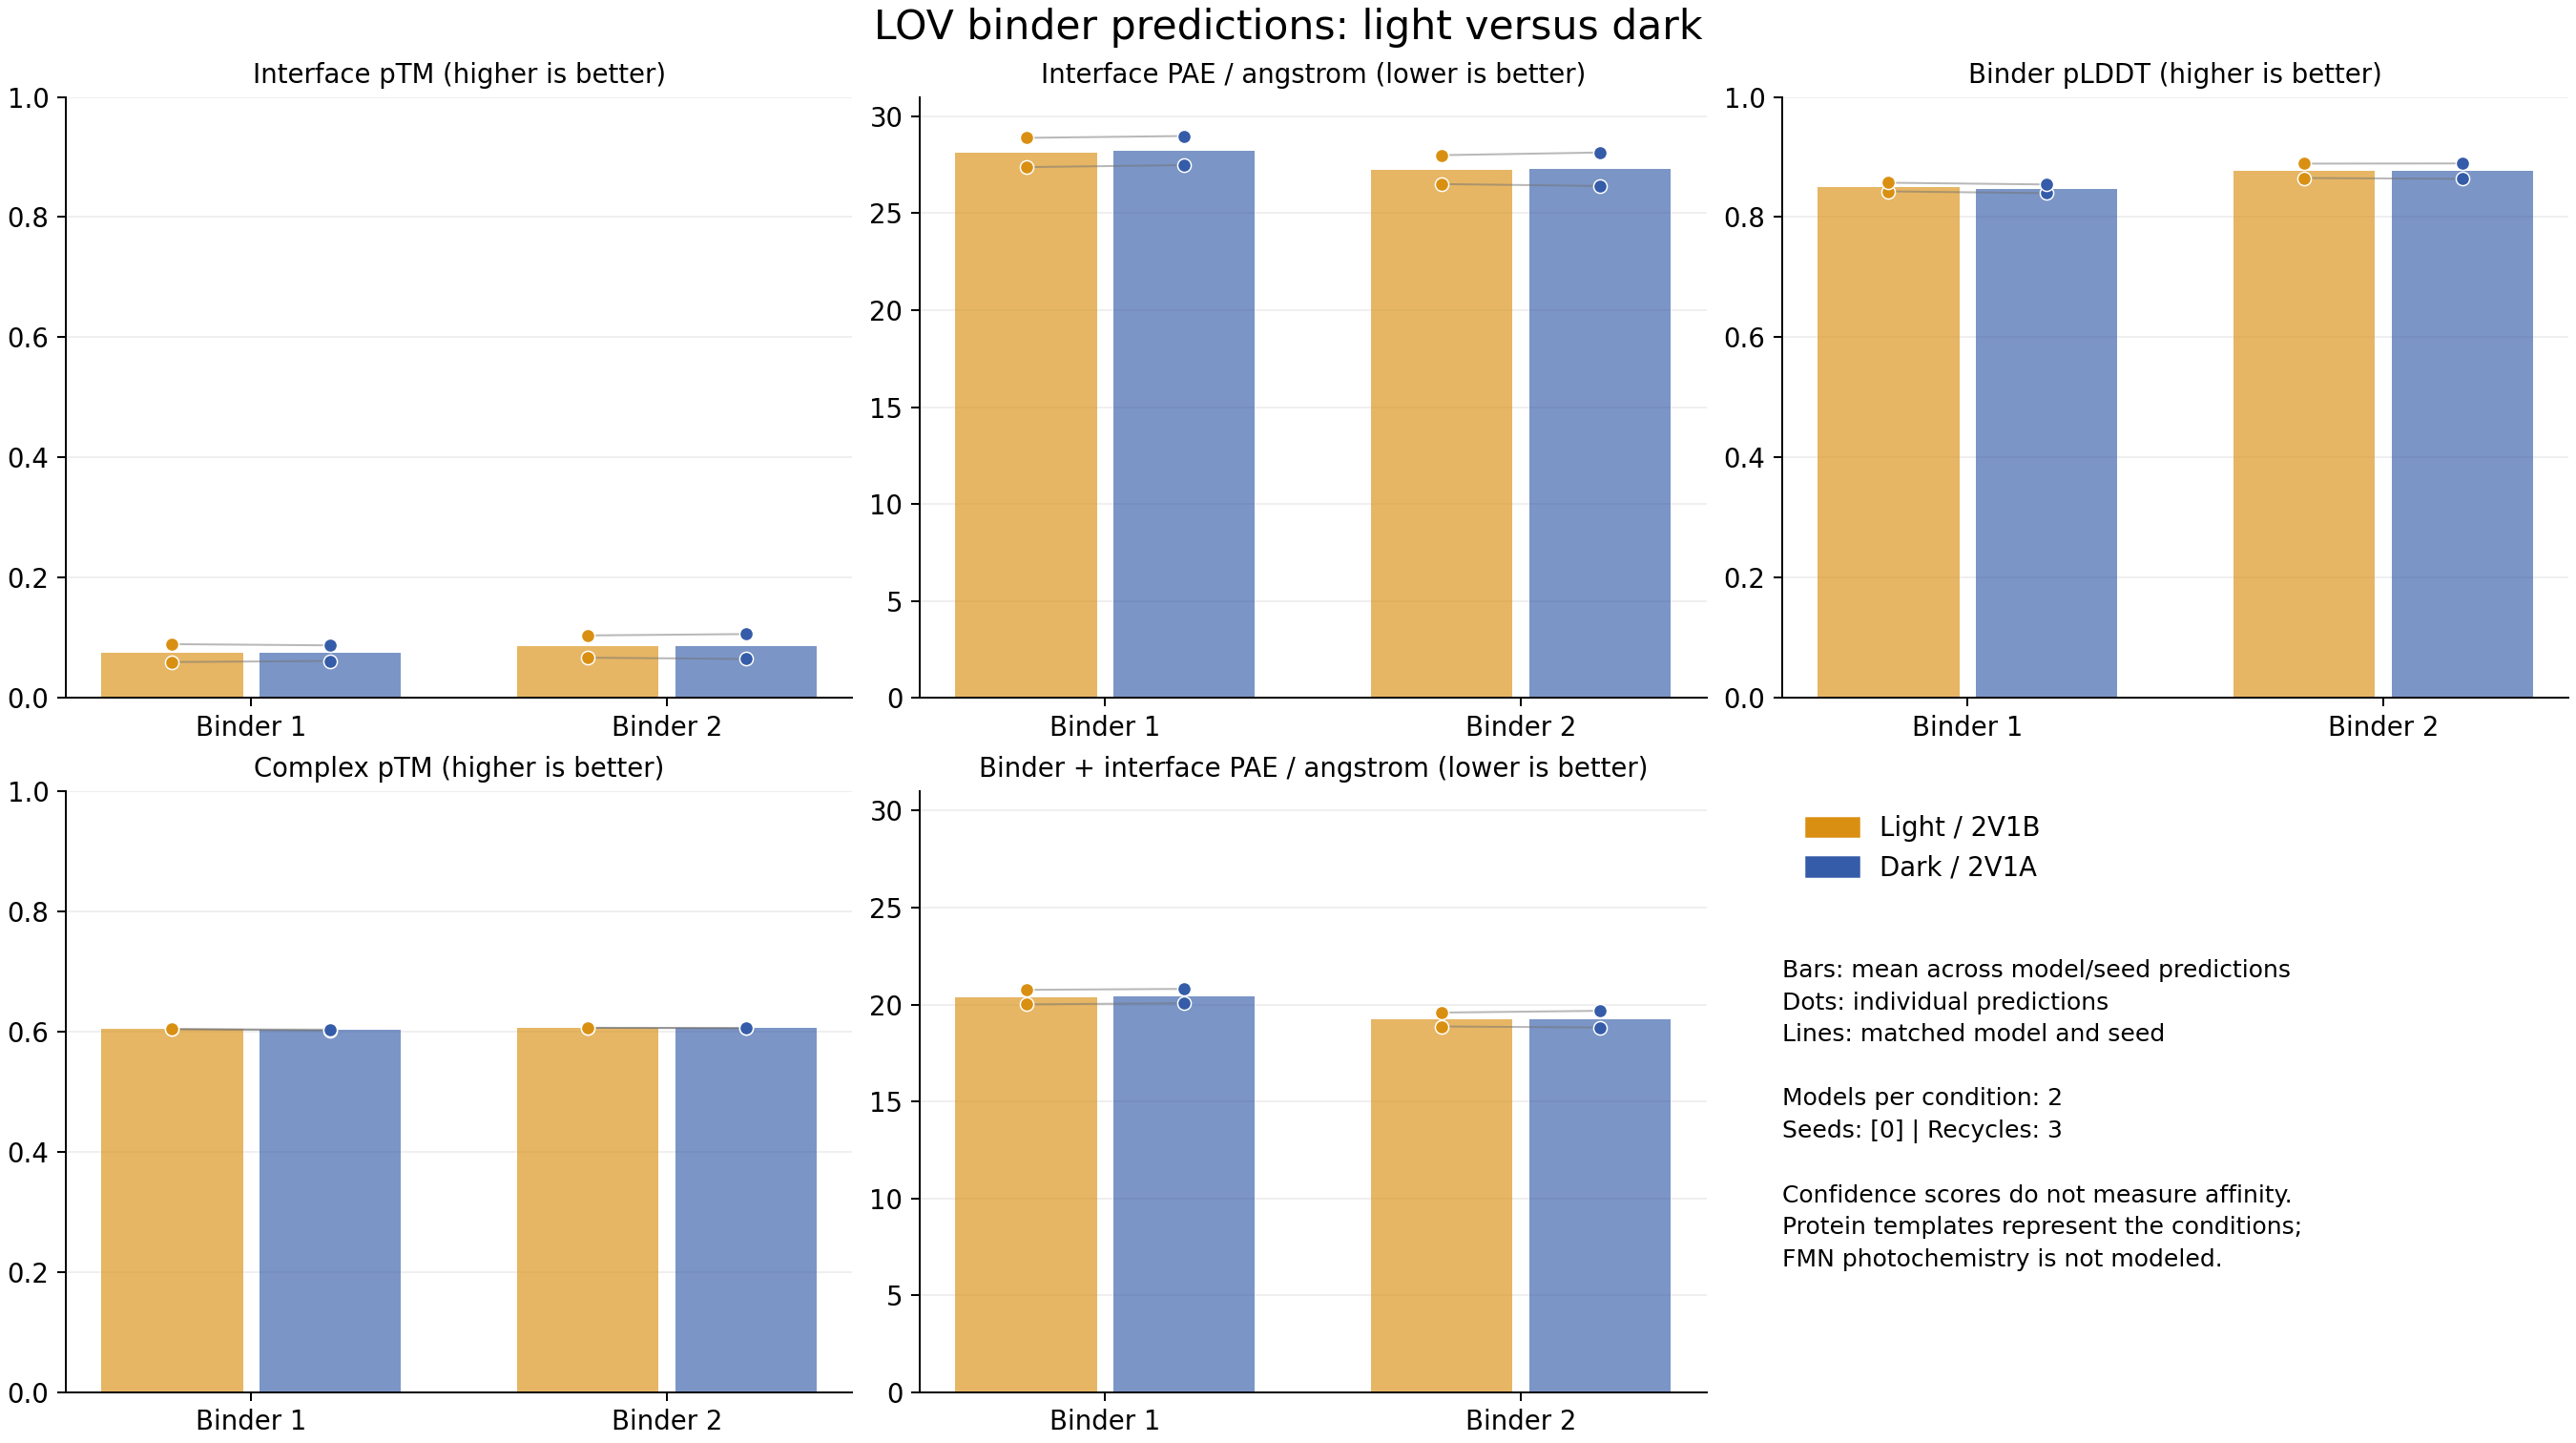

In [181]:
import sys

if str(REPO_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "notebooks"))

from compare_binders_light_dark import show_comparison

comparison_dir = local_path(
    "results/LOV_local/light_dark_comparison/20260912_173545_9d8343"
)

show_comparison(comparison_dir)

In [179]:
import csv

rank_to_test = 1  # Change to 2 for your second accepted binder.

scores_file = (
    local_path(target_settings["design_path"]) / "final_design_stats.csv"
)

with scores_file.open(newline="", encoding="utf-8-sig") as handle:
    designs = list(csv.DictReader(handle))

selected = next(
    (row for row in designs if int(row["Rank"]) == rank_to_test),
    None,
)
if selected is None:
    raise ValueError(f"No accepted design found with rank {rank_to_test}.")

binder_seq = selected["Sequence"].strip()

print("Design:", selected["Design"])
print("Binder length:", len(binder_seq))
print("Sequence:", binder_seq)

Design: LOV_l87_s461542_mpnn2
Binder length: 87
Sequence: SREEIEEFVERELKKLGKEWESLSEEERERIIDVVGDLRKAFADLPEEEQEYVMREYVKLMVDEEFTQKLVDLINESMKKLEEIYNS


In [180]:
results = test_binder(
    TARGET_PDB,
    selected["Design"],
    chain="A",          # Target chain; binder_seq supplies the binder.
    use_multimer=False,
)

Saving predictions to: C:\Users\Feres\Dropbox\Projects\BindCraft\BindCraft\results\LOV_local\binder_tests\LOV_l87_s461542_mpnn2_20260912_172711_da153e
Running in WSL/Linux. This cell stays busy; logs appear when it finishes.
Predicting model_1_ptm...
Predicting model_2_ptm...
Finished: 2 predictions saved.



model,model_name,pLDDT,pTM,i_pTM,pAE,i_pAE
1,model_1_ptm,0.8812,0.8256,0.8492,0.1746,0.2044
2,model_2_ptm,0.9054,0.8520,0.8794,0.1506,0.1736


## Troubleshooting and runtime notes

- **WSL connection fails:** verify `wsl -d Ubuntu` works from PowerShell and that
  `LINUX_PYTHON` points to your Ubuntu environment. The Windows `cuda_env` is not
  the compute environment used here. JAX's NVIDIA support requires Linux/WSL;
  see the [JAX platform matrix](https://docs.jax.dev/en/latest/installation.html).
- **Out of memory:** stop the run and close other GPU jobs. Reduce the size of your
  prepared target and binder, or use a larger GPU. Disabling preallocation reduces
  the initial allocation; it does not reduce the model's required memory. See
  [JAX GPU allocation](https://docs.jax.dev/en/latest/gpu_memory_allocation.html).
- **DSSP missing/failing:** run the local repair cell, then rerun preflight.
  [DSSP package](https://anaconda.org/channels/salilab/packages/dssp/overview).
  Do not point the notebook back to `functions/dssp` on this installation.
- **DAlphaBall library error:** launch through this notebook so the existing
  BindCraft `lib` directory is on `LD_LIBRARY_PATH` for the process and its children.
- **No accepted designs:** the one-trajectory trial is a setup check, not a
  production campaign. Review `failure_csv.csv` and the run log, then deliberately
  increase the trajectory/time limits. Passing filters does not establish binding
  experimentally; see the repository README for interpreting design metrics.
- **Resume:** load a prior run's `target.json`, select the same protocols, and
  increase the limits as needed. A new run saves new snapshots and uses the same
  output folder. Do not mix different targets/settings in a single results folder.
- **Stale lock after a forced shutdown:** inspect the lock's `run_dir` using the
  status cell and verify its processes are gone in WSL before removing that one
  `.bindcraft-notebook.lock` file. The notebook does not remove an unexplained lock.
- **Files and syncing:** outputs are saved in the shared Dropbox checkout. For a
  long campaign you can run Jupyter in WSL and choose a Linux output path to reduce
  shared-filesystem I/O. Back up finished output to Dropbox afterward.

The original notebook, installer, target presets, and pipeline sources are preserved.
No model weights are downloaded by this notebook. Scientific packages are reused
from the existing environment; PyRosetta licensing information is available at
[PyRosetta downloads](https://www.pyrosetta.org/downloads).